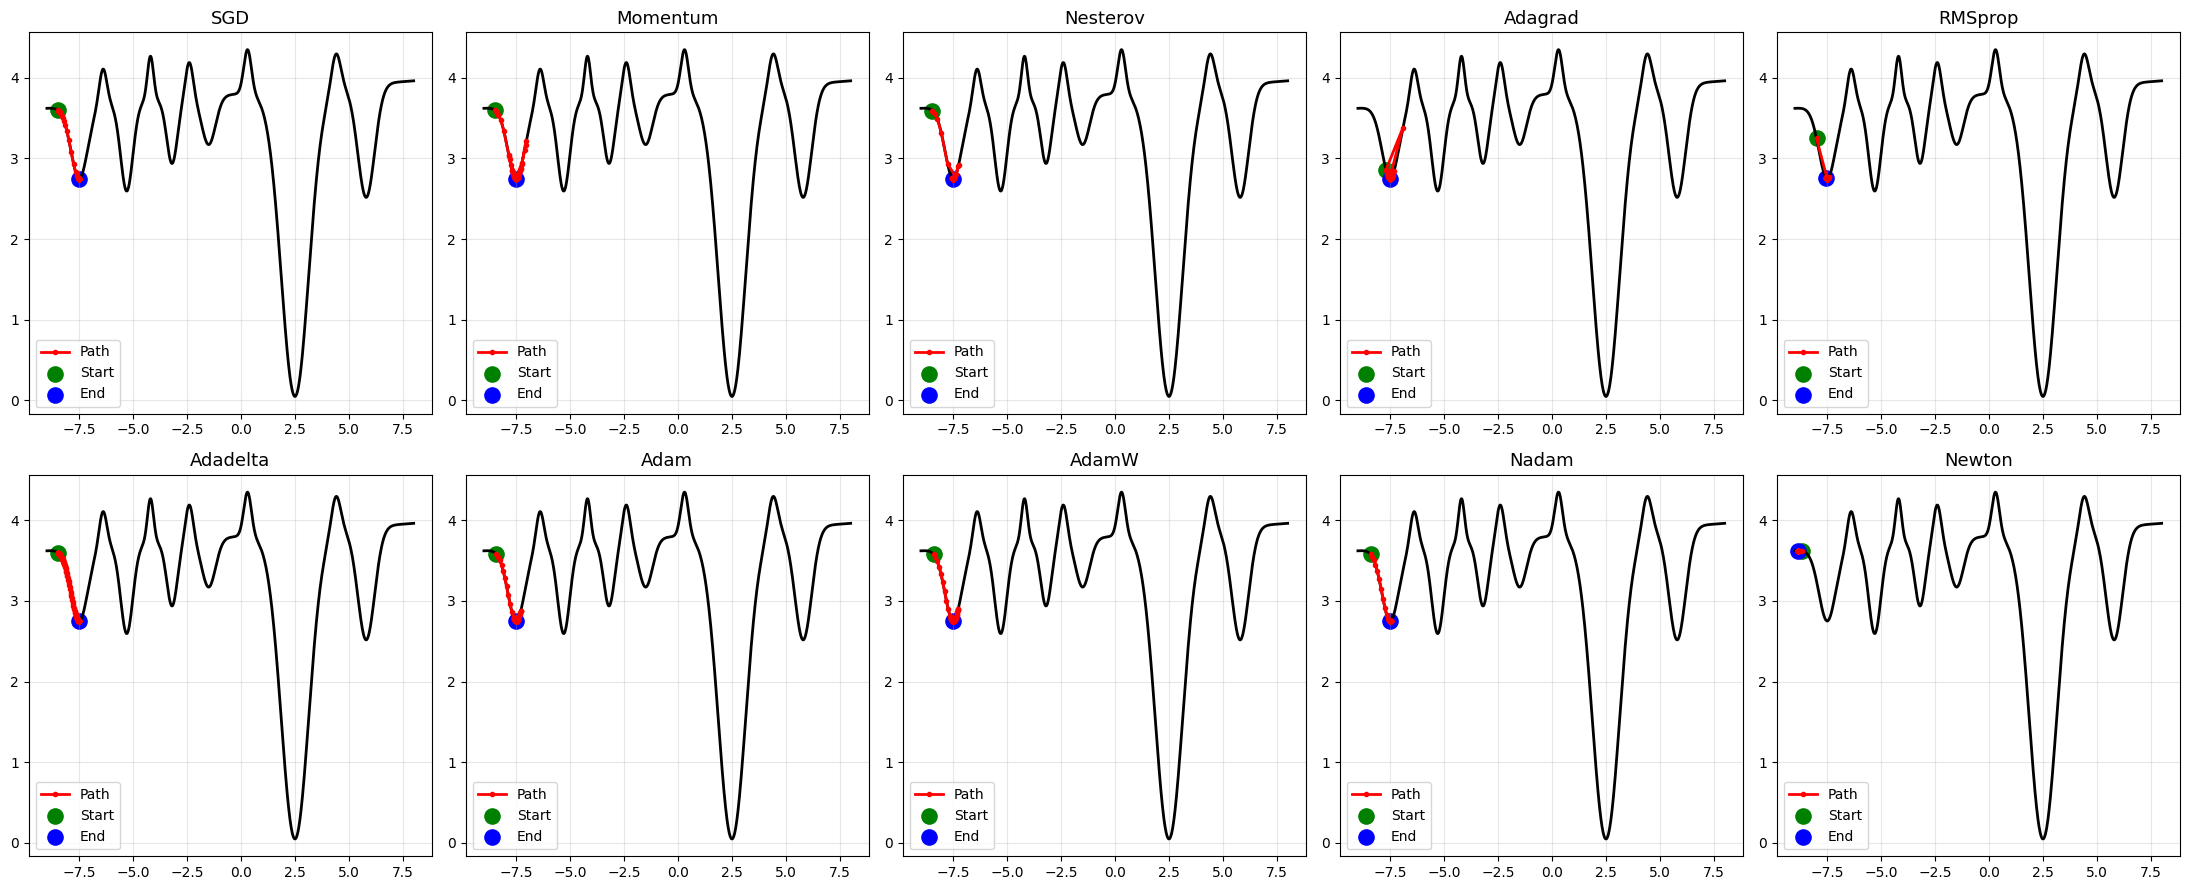

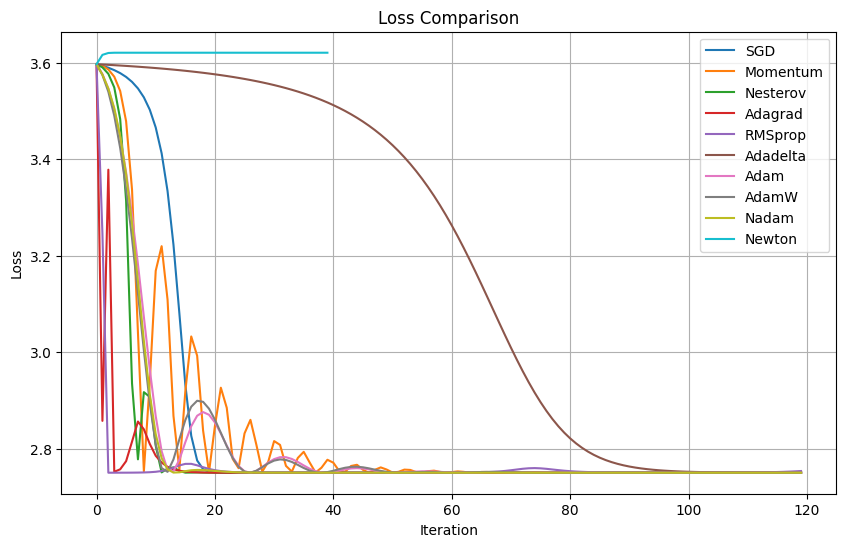

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Start_point = -8.5 # -7.2

########################################################################
# Custom Loss Function
########################################################################

class CustomLoss(torch.nn.Module):

    def forward(self, x):

        y = (
            -0.9*torch.exp(-((x+7.5)/0.55)**2)
            -1.1*torch.exp(-((x+5.3)/0.40)**2)
            -0.8*torch.exp(-((x+3.2)/0.35)**2)
            -0.6*torch.exp(-((x+1.5)/0.45)**2)

            -3.8*torch.exp(-((x-2.5)/0.90)**2)

            -1.4*torch.exp(-((x-5.8)/0.55)**2)

            +0.45*torch.exp(-((x+6.4)/0.25)**2)
            +0.55*torch.exp(-((x+4.2)/0.20)**2)
            +0.45*torch.exp(-((x+2.4)/0.25)**2)
            +0.55*torch.exp(-((x-0.3)/0.25)**2)
            +0.45*torch.exp(-((x-4.4)/0.30)**2)

            +0.02*x
        )

        return y + 3.8


loss_fn = CustomLoss()

########################################################################
# Optimizers
########################################################################

optimizers = {

    "SGD":
        lambda p: torch.optim.SGD(
            p,
            lr=0.08
        ),

    "Momentum":
        lambda p: torch.optim.SGD(
            p,
            lr=0.08,
            momentum=0.9
        ),

    "Nesterov":
        lambda p: torch.optim.SGD(
            p,
            lr=0.08,
            momentum=0.9,
            nesterov=True
        ),

    "Adagrad":
        lambda p: torch.optim.Adagrad(
            p,
            lr=0.8
        ),

    "RMSprop":
        lambda p: torch.optim.RMSprop(
            p,
            lr=0.05
        ),

    "Adadelta":
        lambda p: torch.optim.Adadelta(
            p,
            lr=1.0
        ),

    "Adam":
        lambda p: torch.optim.Adam(
            p,
            lr=0.08
        ),

    "AdamW":
        lambda p: torch.optim.AdamW(
            p,
            lr=0.08
        ),

    "Nadam":
        lambda p: torch.optim.NAdam(
            p,
            lr=0.08
        ),
}

########################################################################
# Newton Optimizer
########################################################################

def newton_step(x):

    loss = loss_fn(x)

    grad = torch.autograd.grad(
        loss,
        x,
        create_graph=True
    )[0]

    hessian = torch.autograd.grad(
        grad,
        x
    )[0]

    with torch.no_grad():

        x -= grad / (hessian + 1e-4)

    return loss


########################################################################
# Run all optimizers
########################################################################

results = {}

epochs = 120

for name, builder in optimizers.items():

    x = torch.tensor([Start_point], requires_grad=True)

    optimizer = builder([x])

    trajectory = []
    losses = []

    for epoch in range(epochs):

        optimizer.zero_grad()

        loss = loss_fn(x)

        loss.backward()

        optimizer.step()

        trajectory.append(x.item())
        losses.append(loss.item())

    results[name] = (trajectory, losses)

########################################################################
# Newton
########################################################################

x = torch.tensor([Start_point], requires_grad=True)

trajectory = []
losses = []

for epoch in range(40):

    loss = newton_step(x)

    trajectory.append(x.item())
    losses.append(loss.item())

    x.requires_grad_(True)

results["Newton"] = (trajectory, losses)

########################################################################
# Create loss landscape
########################################################################

xx = np.linspace(-9, 8, 1000)

yy = []

for i in xx:

    yy.append(
        loss_fn(torch.tensor([i])).item()
    )

########################################################################
# Plot trajectories
########################################################################

# Adjusted to a 2x5 grid to exactly fit all 10 tracking methods
fig, axs = plt.subplots(2, 5, figsize=(22, 9))

axs = axs.ravel()

for ax, (name, (traj, losses)) in zip(axs, results.items()):

    ax.plot(xx, yy, color="black", linewidth=2)

    traj = np.array(traj)

    vals = []

    for t in traj:
        vals.append(
            loss_fn(torch.tensor([t])).item()
        )

    ax.plot(
        traj,
        vals,
        'r.-',
        linewidth=2,
        markersize=6,
        label="Path"
    )

    ax.scatter(
        traj[0],
        vals[0],
        color="green",
        s=120,
        label="Start"
    )

    ax.scatter(
        traj[-1],
        vals[-1],
        color="blue",
        s=120,
        label="End"
    )

    ax.set_title(name, fontsize=13)

    ax.grid(alpha=.3)

    ax.legend()

plt.tight_layout()

########################################################################
# Loss comparison
########################################################################

plt.figure(figsize=(10, 6))

for name, (traj, losses) in results.items():

    plt.plot(losses, label=name)

# plt.yscale("log")

plt.grid()

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.title("Loss Comparison")

plt.legend()

plt.show()

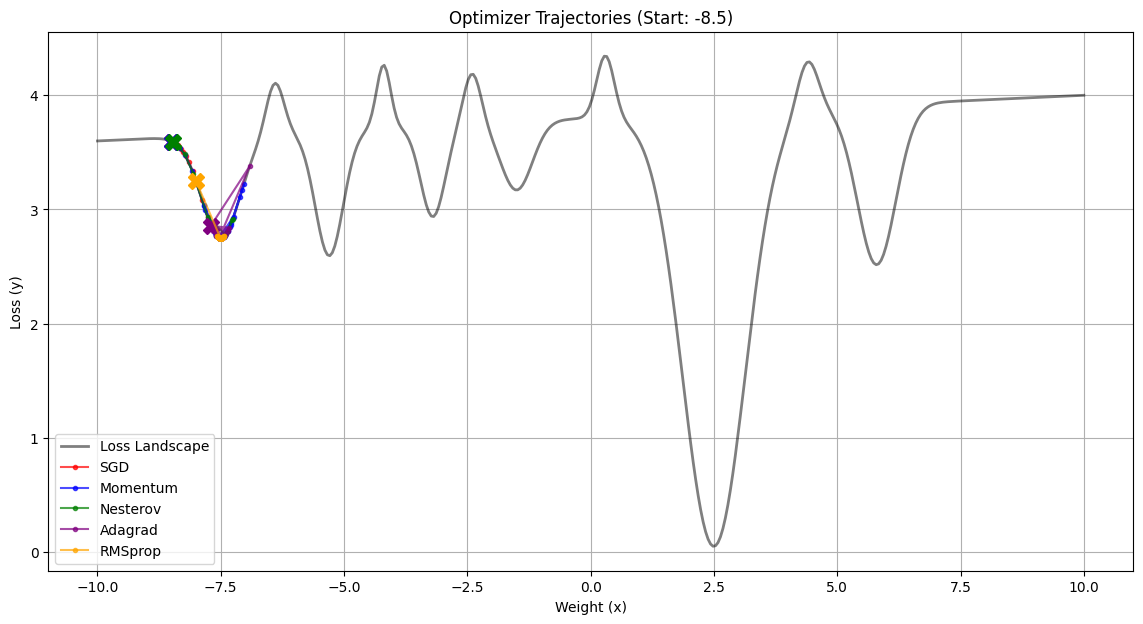

In [3]:
# --- CELL 1: Baseline Comparison of Existing Optimizers ---
import copy

num_steps = 150
paths = {name: [] for name in optimizers.keys()}

# Train each optimizer
for name, opt_lambda in optimizers.items():
    # Initialize a new parameter at the exact same Start_point
    p = torch.tensor([float(Start_point)], requires_grad=True)
    opt = opt_lambda([p])
    
    for i in range(num_steps):
        opt.zero_grad()
        loss = loss_fn(p)
        loss.backward()
        opt.step()
        paths[name].append(p.item())

# Generate the landscape for plotting
x_vals = np.linspace(-10, 10, 400)
# We need to compute the loss for each point to draw the curve
y_vals = [loss_fn(torch.tensor([x], dtype=torch.float32)).item() for x in x_vals]

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(x_vals, y_vals, label="Loss Landscape", color='black', linewidth=2, alpha=0.5)

colors = ['red', 'blue', 'green', 'purple', 'orange']
for (name, path), color in zip(paths.items(), colors):
    y_path = [loss_fn(torch.tensor([x])).item() for x in path]
    plt.plot(path, y_path, marker='.', markersize=6, label=name, color=color, alpha=0.7)
    # Mark the start point with a big X
    plt.plot(path[0], y_path[0], marker='X', markersize=12, color=color) 
    
plt.title(f"Optimizer Trajectories (Start: {Start_point})")
plt.xlabel("Weight (x)")
plt.ylabel("Loss (y)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- CELL 2: The Custom Optimizer Challenge ---

class JitterSGD(torch.optim.Optimizer):
    """
    A custom optimizer that acts like SGD but injects random 'jitter' 
    when gradients get too small to help escape local minima.
    """
    def __init__(self, params, lr=0.1, jitter_strength=0.8, threshold=0.05):
        defaults = dict(lr=lr, jitter_strength=jitter_strength, threshold=threshold)
        super(JitterSGD, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                
                # 1. Apply standard SGD step
                p.add_(grad, alpha=-group['lr'])
                
                # 2. Custom Logic: Escaping traps!
                # If the gradient is smaller than our threshold, add random noise
                if torch.abs(grad) < group['threshold']:
                    noise = (torch.rand_like(p) - 0.5) * group['jitter_strength']
                    p.add_(noise)

        return loss

# Test our new JitterSGD
p_custom = torch.tensor([float(Start_point)], requires_grad=True)
opt_custom = JitterSGD([p_custom], lr=0.08, jitter_strength=1.5, threshold=0.1)

custom_path = []
for i in range(num_steps):
    opt_custom.zero_grad()
    loss = loss_fn(p_custom)
    loss.backward()
    opt_custom.step()
    custom_path.append(p_custom.item())

# Plot the custom optimizer's path
plt.figure(figsize=(14, 5))
plt.plot(x_vals, y_vals, label="Loss Landscape", color='black', linewidth=2, alpha=0.5)

y_custom = [loss_fn(torch.tensor([x])).item() for x in custom_path]
plt.plot(custom_path, y_custom, marker='o', markersize=5, label="JitterSGD (Custom)", color='magenta')
plt.plot(custom_path[0], y_custom[0], marker='X', markersize=12, color='magenta')

plt.title(f"Custom Optimizer: JitterSGD Trajectory (Start: {Start_point})")
plt.xlabel("Weight (x)")
plt.ylabel("Loss (y)")
plt.legend()
plt.grid(True)
plt.show()